In [7]:
import cv2
import os

model_dir = "Age-Gender"

face_proto = os.path.join(model_dir, "opencv_face_detector.pbtxt")
face_model = os.path.join(model_dir, "opencv_face_detector_uint8.pb")
age_proto = os.path.join(model_dir, "age_deploy.prototxt")
age_model = os.path.join(model_dir, "age_net.caffemodel")
gender_proto = os.path.join(model_dir, "gender_deploy.prototxt")
gender_model = os.path.join(model_dir, "gender_net.caffemodel")

face_net = cv2.dnn.readNet(face_model, face_proto)
age_net = cv2.dnn.readNet(age_model, age_proto)
gender_net = cv2.dnn.readNet(gender_model, gender_proto)

ageList = ["(0-2)", "(4-6)", "(8-12)", "(15-20)", "(25-32)", "(38-43)", "(48-53)", "(60-100)"]
genderList = ["Male", "Female"]
MODEL_MEAN_VALUES = (78.4263377603, 87.7689143744, 114.895847746)

### 1. Environment Setup and Model Initialization

In the initial step, the necessary libraries (`cv2` and `os`) are imported to handle image processing and path operations. We establish the relative directory paths for the pre-trained weights and configuration files corresponding to the face detection, age estimation, and gender prediction models. 

Following the project instructions, all three models are loaded into memory utilizing OpenCV's Deep Neural Network module (`cv2.dnn.readNet`). Finally, the exact predefined classification categories for age (`ageList`), gender (`genderList`), and the specific mean values (`MODEL_MEAN_VALUES`) required for subsequent input normalization are declared.

In [8]:
def highlightFace(net, frame, conf_threshold=0.7):
    frameOpencvDnn = frame.copy()
    h, w = frameOpencvDnn.shape[:2]
    
    blob = cv2.dnn.blobFromImage(frameOpencvDnn, 1.0, (300, 300), (104, 117, 123), True, False)
    net.setInput(blob)
    detections = net.forward()
    
    faceBoxes = []
    for i in range(detections.shape[2]):
        confidence = detections[0, 0, i, 2]
        if confidence > conf_threshold:
            x1 = int(detections[0, 0, i, 3] * w)
            y1 = int(detections[0, 0, i, 4] * h)
            x2 = int(detections[0, 0, i, 5] * w)
            y2 = int(detections[0, 0, i, 6] * h)
            faceBoxes.append([x1, y1, x2, y2])
            cv2.rectangle(frameOpencvDnn, (x1, y1), (x2, y2), (0, 255, 0), 2)
            
    return frameOpencvDnn, faceBoxes

### 2. Face Detection and Highlighting

In this step, we define the `highlightFace` function to isolate faces within an input frame. The image is first pre-processed into a neural network-compatible blob using `cv2.dnn.blobFromImage`. This transformation applies a scaling factor of `1.0`, resizes the image to `300x300` pixels, applies mean subtraction using the values `(104, 117, 123)`, and performs RGB channel swapping. 

The resulting blob is fed into the face detection model. We then parse the forward pass results, filtering out any weak predictions by enforcing a minimum confidence threshold (`conf_threshold = 0.7`). For all valid detections, the coordinates are mapped back to the original frame dimensions, and green bounding boxes are drawn around the detected faces. The function returns the annotated frame along with the list of bounding box coordinates.

In [9]:
def detect_face_age_gender(frame, face_net, age_net, gender_net, blur_face=False):
    resultImg, faceBoxes = highlightFace(face_net, frame)
    if not faceBoxes:
        return resultImg
    
    padding = 20
    for bbox in faceBoxes:
        y1 = max(0, bbox[1] - padding)
        y2 = min(frame.shape[0] - 1, bbox[3] + padding)
        x1 = max(0, bbox[0] - padding)
        x2 = min(frame.shape[1] - 1, bbox[2] + padding)
        face = frame[y1:y2, x1:x2]
        if face.size == 0: 
            continue
            
        if blur_face: 
            face = cv2.GaussianBlur(face, (51, 51), 0)
        blob = cv2.dnn.blobFromImage(face, 1.0, (227, 227), MODEL_MEAN_VALUES, swapRB=False)
        
        gender_net.setInput(blob)
        gender = genderList[gender_net.forward()[0].argmax()]
        age_net.setInput(blob)
        age = ageList[age_net.forward()[0].argmax()]
        
        label = f'{gender}, {age}'
        cv2.putText(resultImg, label, (bbox[0], bbox[1] - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 255), 2, cv2.LINE_AA)
    return resultImg

### 3. Age and Gender Prediction Pipeline 

In this step, the core pipeline for face, age, and gender inference is implemented. 

1. **Face Localization:** The function initially calls `highlightFace` to retrieve the frame annotated with bounding boxes and the corresponding coordinate list. 
2. **Region Extraction:** For each detected face, the algorithm extracts the facial region using a precise 20-pixel padding to capture the entire head structure. Boundary safety checks (`max()` and `min()`) are strictly enforced to prevent array slicing errors at the image borders.
3. **Conditional Blurring:** To accommodate the later robustness experiments, an optional `blur_face` parameter is included to apply a 51x51 Gaussian filter specifically to the extracted face region before inference.
4. **Blob Processing:** The isolated face crop is transformed into a secondary blob. Following the model's architectural requirements, this blob is scaled to `227x227` pixels, normalized using the predefined `MODEL_MEAN_VALUES`, and the color channels are kept in their original order (`swapRB=False`).
5. **Inference & Annotation:** The processed blob is sequentially fed into the gender and age networks. The networks perform a forward pass, the highest probability classes are extracted using `.argmax()`, and the combined prediction string is drawn on the image directly above the bounding box.

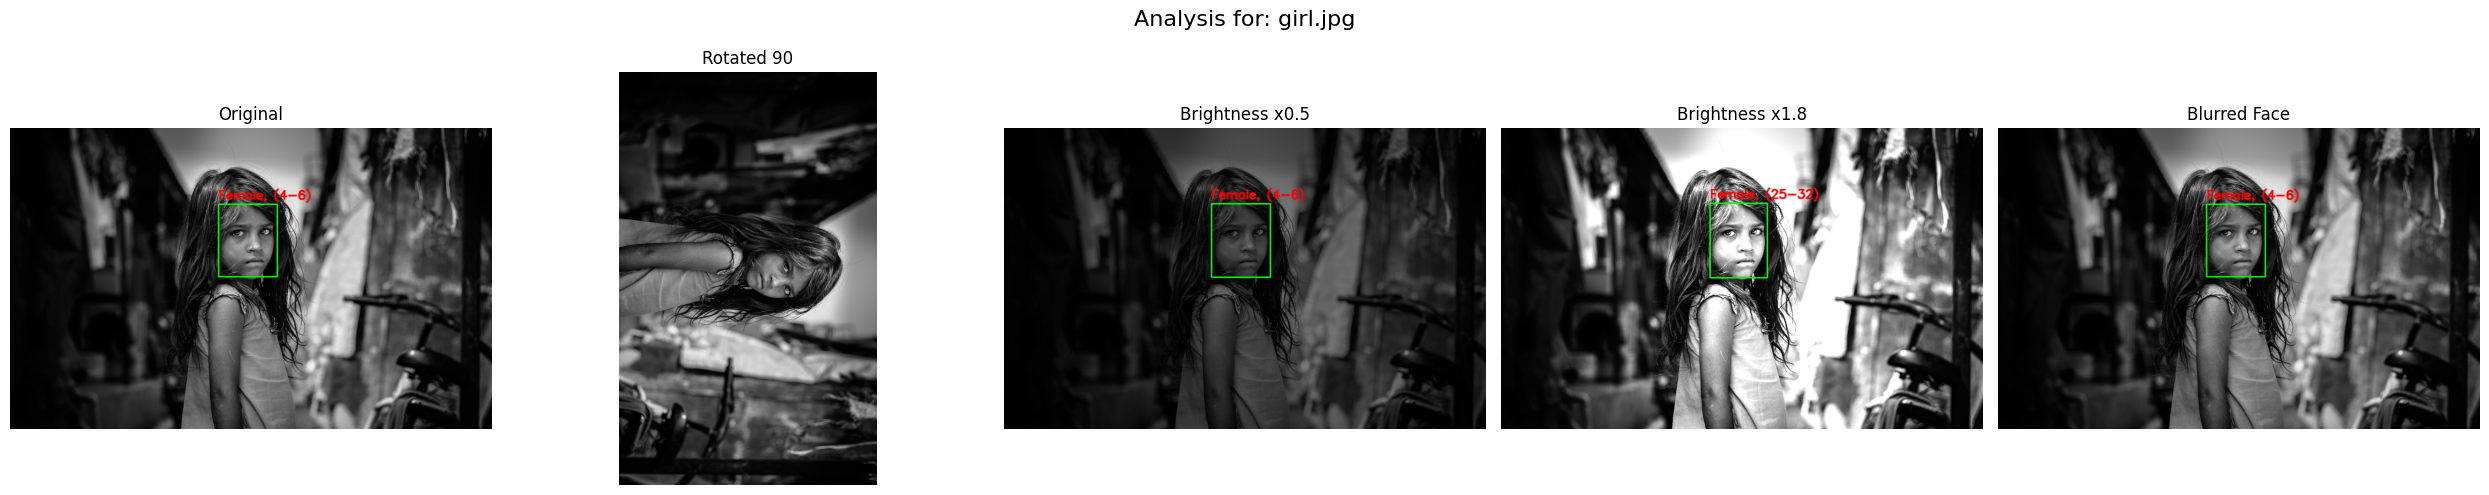

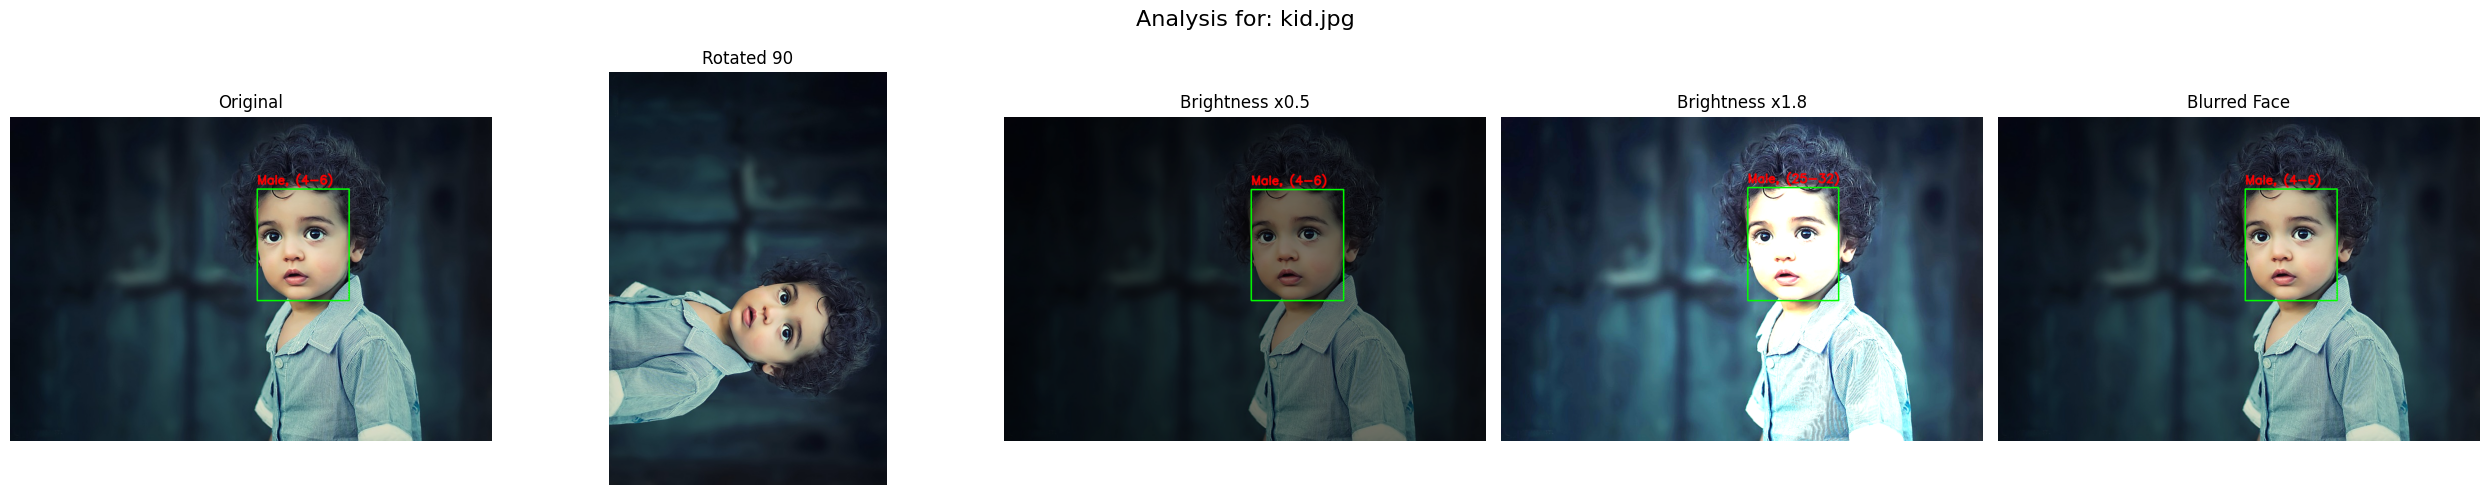

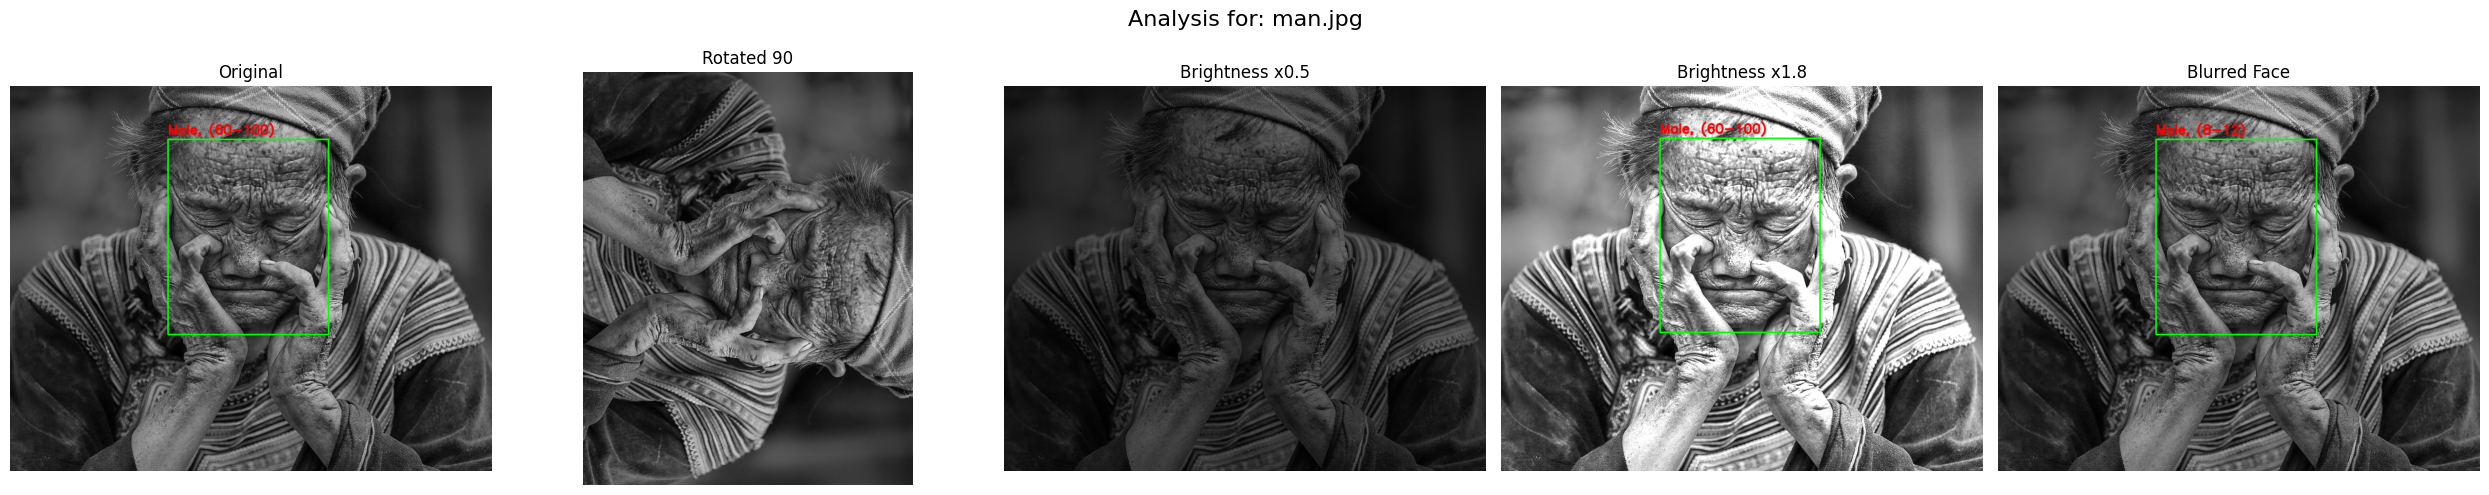

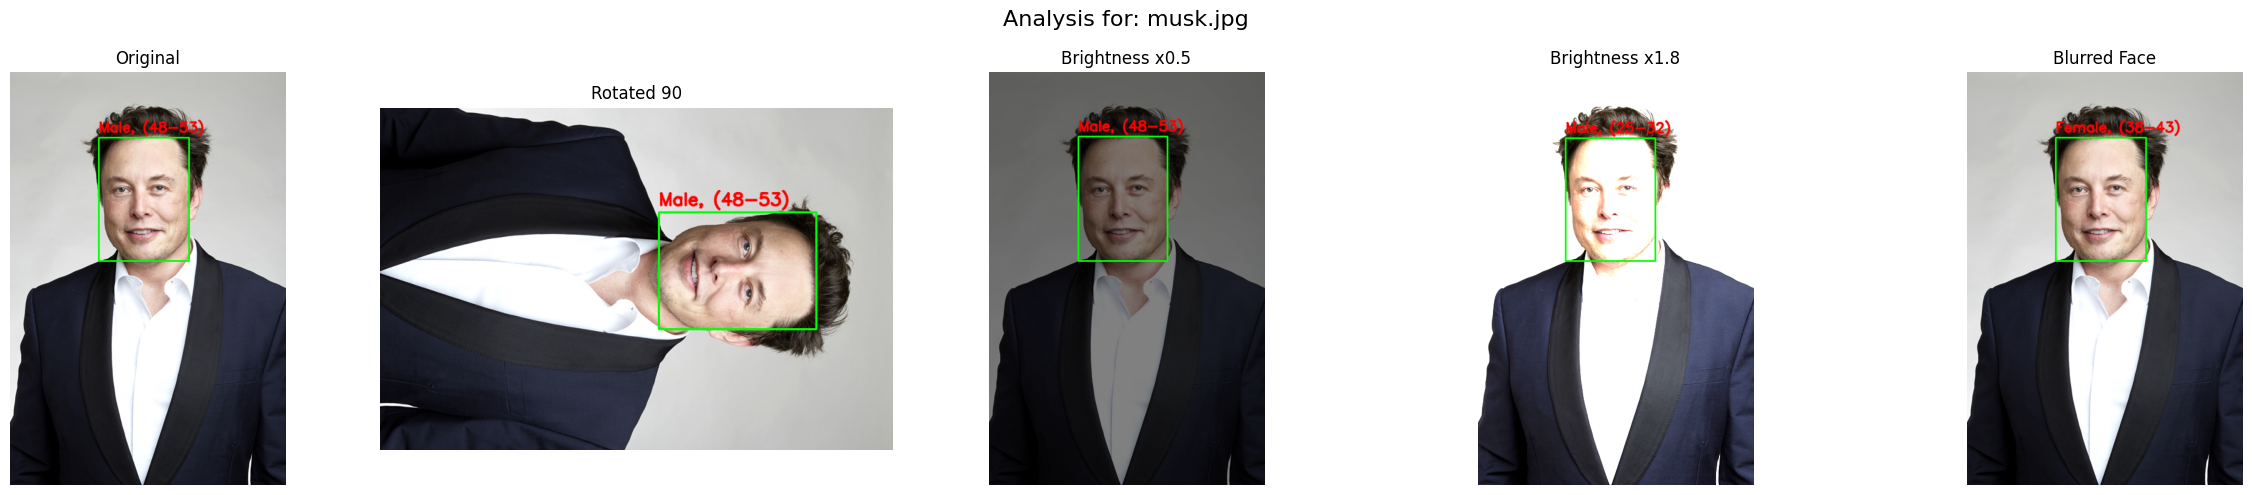

In [10]:
import matplotlib.pyplot as plt
import time

image_names = ["girl.jpg", "kid.jpg", "man.jpg", "musk.jpg"]

for img_name in image_names:
    img_path = os.path.join(model_dir, img_name)
    img = cv2.imread(img_path)
    if img is None: continue
        
    fig, axes = plt.subplots(1, 5, figsize=(25, 5))
    fig.suptitle(f"Analysis for: {img_name}", fontsize=16)
    
    # original
    axes[0].imshow(cv2.cvtColor(detect_face_age_gender(img, face_net, age_net, gender_net), cv2.COLOR_BGR2RGB))
    axes[0].set_title("Original"); axes[0].axis('off')
    
    # rot 90
    axes[1].imshow(cv2.cvtColor(detect_face_age_gender(cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE), face_net, age_net, gender_net), cv2.COLOR_BGR2RGB))
    axes[1].set_title("Rotated 90"); axes[1].axis('off')
    
    # dark
    axes[2].imshow(cv2.cvtColor(detect_face_age_gender(cv2.convertScaleAbs(img, alpha=0.5, beta=0), face_net, age_net, gender_net), cv2.COLOR_BGR2RGB))
    axes[2].set_title("Brightness x0.5"); axes[2].axis('off')
    
    # bright
    axes[3].imshow(cv2.cvtColor(detect_face_age_gender(cv2.convertScaleAbs(img, alpha=1.8, beta=0), face_net, age_net, gender_net), cv2.COLOR_BGR2RGB))
    axes[3].set_title("Brightness x1.8"); axes[3].axis('off')
    
    # blur
    axes[4].imshow(cv2.cvtColor(detect_face_age_gender(img, face_net, age_net, gender_net, blur_face=True), cv2.COLOR_BGR2RGB))
    axes[4].set_title("Blurred Face"); axes[4].axis('off')
    
    plt.tight_layout(); plt.show()

### 4. Experimental Evaluation and Robustness Analysis (Steps 5 & 6)

In this section, we evaluate the robustness of the pre-trained Face, Age, and Gender models against various image perturbations. The pipeline iterates through the dataset and visualizes the model's performance across five states: the original image, a 90-degree spatial rotation, decreased brightness (x0.5), increased brightness (x1.8), and a 51x51 Gaussian blur applied strictly to the extracted facial region.

Based on the empirical outputs, we observe the following specific behaviors and vulnerabilities of the models:

* **A. 90-Degree Rotation:** * *Analysis:* Standard face detection networks, particularly those without heavy rotation augmentation during training, are highly sensitive to spatial orientation. 
    * *Observation:* The face detector failed completely for three of the four subjects (`girl`, `kid`, and `man`). It only successfully detected the face in `musk.jpg`, indicating that while the model is largely rotation-variant, exceptionally prominent frontal features can sometimes bypass this limitation.

* **B. Decreased Brightness (x0.5):**
    * *Analysis:* Deepening shadows can obscure the pixel gradients and contrast that Convolutional Neural Networks rely on to draw bounding boxes.
    * *Observation:* The detector failed to locate the face in `man.jpg`, likely because the subject's deep wrinkles and features blended into the darkened image. However, the model proved surprisingly robust for the other three subjects, maintaining the exact same age and gender predictions as their original baseline images.

* **C. Increased Brightness (x1.8):**
    * *Analysis:* Overexposure acts as a destructive filter, washing out fine skin textures, lines, and structural shadows that are critical for the age prediction network.
    * *Observation:* This perturbation severely confused the age estimator. The children (`girl` and `kid`) were incorrectly classified as much older (`25-32`), while `musk.jpg` was classified as much younger (`25-32`). When high-frequency skin detail is washed out by bright light, the model appears to default heavily toward an average middle-adult bracket.

* **D. Intentional Face Blurring (Gaussian 51x51):**
    * *Analysis:* Blurring acts as a low-pass filter, erasing high-frequency details like wrinkles, stubble, and sharp edge structures.
    * *Observation:* This caused drastic failures on the adult subjects. The older man's age prediction plummeted from `(60-100)` to a child's bracket `(8-12)` because the blur completely erased his wrinkles, simulating smooth skin. Furthermore, softening the structural features of `musk.jpg` caused the gender model to fail entirely, misclassifying the subject as Female. 
    * Interestingly, the predictions for the children (`girl` and `kid`) remained perfectly stable at `(4-6)`. This highlights a key technical insight: because children's faces naturally possess smooth textures with very few high-frequency details, the applied blur filter did not destroy the specific low-frequency structural features the model relies on to identify their age bracket.

In [11]:
video_path = os.path.join(model_dir, "Jobs_2 .mp4")
out_path = os.path.join(model_dir, "Jobs_2_output.mp4")
cap = cv2.VideoCapture(video_path)

if cap.isOpened():
    out = cv2.VideoWriter(out_path, cv2.VideoWriter_fourcc(*'mp4v'), int(cap.get(cv2.CAP_PROP_FPS)), 
                          (int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)), int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))))
    prev_time = 0
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret: break
        
        cur_time = time.time()
        fps = 1 / (cur_time - prev_time) if prev_time > 0 else 0
        prev_time = cur_time
        
        res_frame = detect_face_age_gender(frame, face_net, age_net, gender_net)
        cv2.putText(res_frame, f"FPS: {int(fps)}", (20, 50), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2, cv2.LINE_AA)
        out.write(res_frame)
        
    cap.release()
    out.release()

### 5. Real-Time Video Processing

In the final step of this section, the static image pipeline is extended to process video data. A script is implemented to read `Jobs_2 .mp4` frame by frame and apply the previously defined `detect_face_age_gender` inference function.

**Implementation Details:**
1. **Video Initialization:** The script utilizes `cv2.VideoCapture` to load the input video and extracts critical metadata, including the original frame width, height, and Frames Per Second (FPS). A `cv2.VideoWriter` object is then initialized using the `mp4v` codec to compile the processed frames into a new output video (`Jobs_2_output.mp4`).
2. **Frame-by-Frame Processing:** Within a `while` loop, each frame is sequentially read and passed into the `detect_face_age_gender` pipeline to extract bounding boxes and overlay the Age/Gender predictions.
3. **FPS Calculation and Display:** To monitor performance, the processing speed is calculated in real-time by measuring the time elapsed (`time.time()`) between consecutive frames. This dynamic FPS value is overlaid onto the top-left corner of the video using `cv2.putText` before the frame is written to the output file. 
4. **Resource Management:** Finally, upon processing all frames, the `release()` method is called on both the capture and writer objects to safely free system resources.